# Google Colab 데이터 로드

In [4]:
#Step 1. 구글 코랩에 한글 폰트 설정하기
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
'rm' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
#Step 1.분석할 데이터가 저장된 파일을 불러와서 변수에 할당합니다.
from google.colab import files
myfile = files.upload()
import io
import pandas as pd
#pd.read_csv로 csv파일 불러오기
study = pd.read_csv(io.BytesIO(myfile['공부시간과시험점수.csv']),
                       encoding='cp949')
study

ModuleNotFoundError: No module named 'google.colab'

# 로컬 데이터 로드

In [7]:
#컴퓨터에서 작업하려면 아래 코드의 주석을 제거하고 실행하면 됩니다
import pandas as pd
study = pd.read_csv('./머신러닝실습용자료/공부시간과시험점수.csv',encoding='cp949')
study

# 이름 -> 의미 없음 분석 때 사용하지 않음
# 공부 시간 -> feature (특징)
# 시험 점수 -> target(예측 결과)

,이름,공부시간,시험점수
0,이원재,15.0,85.0
1,맹승주,14.5,86.5
2,안미경,14.0,86.0
3,서진수,13.5,85.5
4,황경인,13.0,85.0
5,신운무,12.0,83.0
6,권율,12.0,85.0
7,강준,11.0,82.0
8,신사임당,11.0,83.0
9,문무왕,10.5,82.0


# 공통 실습 코드

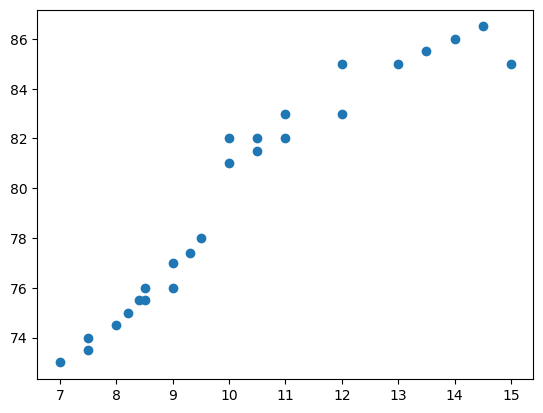

In [9]:
# data, target 정의
data = study['공부시간']
target = study['시험점수']

# 산점도 그리기
import matplotlib.pyplot as plt
plt.plot(data,target,'o')
plt.show()

In [10]:
import numpy as np

# train, test 데이터 나누기 위해 numpy로 변경
data = study['공부시간'].to_numpy()
target = study['시험점수'].to_numpy()

# 훈련 세트와 테스트 세트로 나눕니다.
from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(data, target, test_size = 0.2, random_state = 40)
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=40)

In [ ]:
# shape 확인
훈련용_data.shape

(20, 1)


In [ ]:
# data 전체 확인
훈련용_data

In [16]:
# reshape 함수에 -1을 넣으면, rows은 자동으로 입력해달라는 뜻
# 즉, column을 1개로 내가 정했으니, 남은 데이터는 알아서 row에 잘 넣어주세요.
훈련용_data = X_train.reshape(-1, 1)
테스트용_data = X_test.reshape(-1, 1)

In [15]:
# shape 확인
훈련용_data.shape

(20, 1)

In [ ]:
# data 전체 확인
훈련용_data

In [ ]:
# 선형회귀모델 학습
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(훈련용_data, 훈련용_target)

In [ ]:
# 점수 확인(lr.score는 결정계수R2에 대한 정확도를 의미합니다.)
print(lr.score(훈련용_data , 훈련용_target))
print(lr.score(테스트용_data , 테스트용_target))

In [ ]:
# 16이라는 값을 넣었을 때 예상 결과값 확인
lr.predict([[16]])

In [ ]:
# 회귀계수 확인
print(lr.coef_ , lr.intercept_)

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(훈련용_data , 훈련용_target)
plt.plot( [5,18], [5*lr.coef_ +lr.intercept_ ,
                    18*lr.coef_ + lr.intercept_])
plt.scatter(16 , 90 ,marker="^")
plt.show()

## 다항회귀분석 적용

In [ ]:
# 다항회귀분석 적용
import numpy as np
훈련용_data_poly = np.column_stack(( 훈련용_data ** 2, 훈련용_data))
테스트용_data_poly = np.column_stack((테스트용_data ** 2 , 테스트용_data))

lr = LinearRegression()
lr.fit(훈련용_data_poly , 훈련용_target)
lr.score(테스트용_data_poly , 테스트용_target)

In [ ]:
lr.predict([[16**2,16]])

In [ ]:
print(lr.score(훈련용_data_poly , 훈련용_target))
print(lr.score(테스트용_data_poly , 테스트용_target))